# Day 8 — Feature Importance and Leakage Investigation

## Objective

Interpret the Random Forest model, identify the features contributing most strongly to predictions, and investigate possible reasons for the unusually high predictive performance observed during baseline evaluation and cross-validation.

The analysis will include:

- Random Forest impurity-based feature importance
- Permutation importance on held-out test data
- Train-test feature-profile overlap
- Predictor-profile and target consistency
- Feature ablation experiments
- Investigation of potential leakage or overly direct predictors

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
REPORTS_DIR = PROJECT_ROOT / "reports"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Figures directory:", FIGURES_DIR)
print("Reports directory:", REPORTS_DIR)

Project root: /Users/home/Desktop/AthleteIQ/athleteiq-performance-prediction
Data directory: /Users/home/Desktop/AthleteIQ/athleteiq-performance-prediction/data/processed
Figures directory: /Users/home/Desktop/AthleteIQ/athleteiq-performance-prediction/figures
Reports directory: /Users/home/Desktop/AthleteIQ/athleteiq-performance-prediction/reports


In [3]:
X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test = pd.read_csv(DATA_DIR / "X_test.csv")

y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze("columns")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (299, 27)
X_test shape: (75, 27)
y_train shape: (299,)
y_test shape: (75,)


In [4]:
print("Target present in X_train:", "Quality of Sleep" in X_train.columns)
print("Target present in X_test:", "Quality of Sleep" in X_test.columns)

print("\nMissing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test:", X_test.isna().sum().sum())

print("\nAll X_train columns numeric:", all(pd.api.types.is_numeric_dtype(X_train[col]) for col in X_train.columns))
print("All X_test columns numeric:", all(pd.api.types.is_numeric_dtype(X_test[col]) for col in X_test.columns))

assert "Quality of Sleep" not in X_train.columns
assert "Quality of Sleep" not in X_test.columns
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

Target present in X_train: False
Target present in X_test: False

Missing values in X_train: 0
Missing values in X_test: 0

All X_train columns numeric: True
All X_test columns numeric: True


In [5]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

test_predictions = rf_model.predict(X_test)

test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_r2 = r2_score(y_test, test_predictions)

print(f"Random Forest Test MAE: {test_mae:.4f}")
print(f"Random Forest Test RMSE: {test_rmse:.4f}")
print(f"Random Forest Test R²: {test_r2:.4f}")

Random Forest Test MAE: 0.0391
Random Forest Test RMSE: 0.1338
Random Forest Test R²: 0.9881


In [6]:
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df

,Feature,Importance
0,Sleep Duration,0.794060
1,Stress Level,0.100867
2,Occupation_Doctor,0.035611
3,Heart Rate,0.033957
4,Daily Steps,0.009012
5,Age,0.008435
6,Occupation_Accountant,0.005143
7,BMI Category_Normal,0.002839
8,Diastolic BP,0.001763
9,Systolic BP,0.001254


In [7]:
feature_importance_path = REPORTS_DIR / "random_forest_feature_importance.csv"

feature_importance_df.to_csv(
    feature_importance_path,
    index=False
)

print("Saved:", feature_importance_path)

Saved: /Users/home/Desktop/AthleteIQ/athleteiq-performance-prediction/reports/random_forest_feature_importance.csv


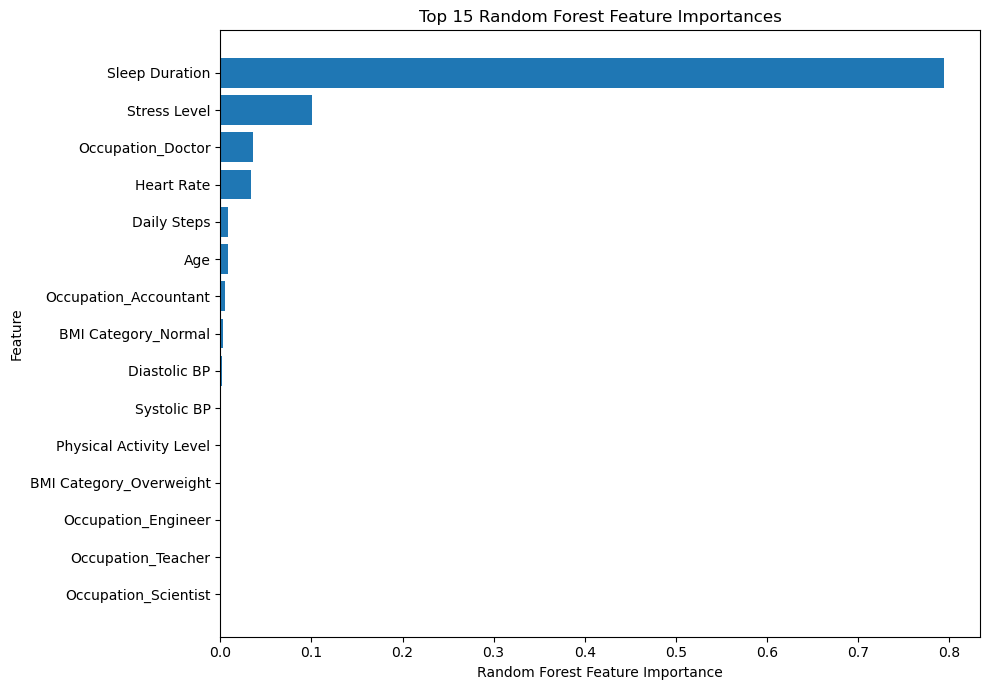

Saved: /Users/home/Desktop/AthleteIQ/athleteiq-performance-prediction/figures/random_forest_feature_importance.png


In [8]:
top_n = 15

top_features = feature_importance_df.head(top_n).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()

importance_figure_path = FIGURES_DIR / "random_forest_feature_importance.png"

plt.savefig(
    importance_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", importance_figure_path)

## Interpreting Random Forest Feature Importance

Random Forest impurity-based feature importance measures how much each feature contributes to reducing prediction error across the model's decision trees.

A larger importance value indicates that the model relied more heavily on that feature.

However, feature importance does not establish causation. It can also be affected by correlated features and the structure of the dataset.

Therefore, permutation importance will also be evaluated using the held-out test set.

In [9]:
permutation_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Permutation Importance Mean": permutation_result.importances_mean,
    "Permutation Importance Std": permutation_result.importances_std
}).sort_values(
    "Permutation Importance Mean",
    ascending=False
).reset_index(drop=True)

permutation_importance_df

,Feature,Permutation Importance Mean,Permutation Importance Std
0,Sleep Duration,1.151418,0.191223
1,Stress Level,0.124749,0.027014
2,Occupation_Doctor,0.055021,0.011466
3,Heart Rate,0.047330,0.010317
4,Daily Steps,0.017404,0.004070
5,Age,0.014064,0.003980
6,Occupation_Accountant,0.005157,0.002129
7,BMI Category_Normal,0.005085,0.002134
8,Physical Activity Level,0.003684,0.001363
9,Occupation_Engineer,0.001481,0.000493


In [10]:
permutation_path = REPORTS_DIR / "random_forest_permutation_importance.csv"

permutation_importance_df.to_csv(
    permutation_path,
    index=False
)

print("Saved:", permutation_path)

Saved: /Users/home/Desktop/AthleteIQ/athleteiq-performance-prediction/reports/random_forest_permutation_importance.csv


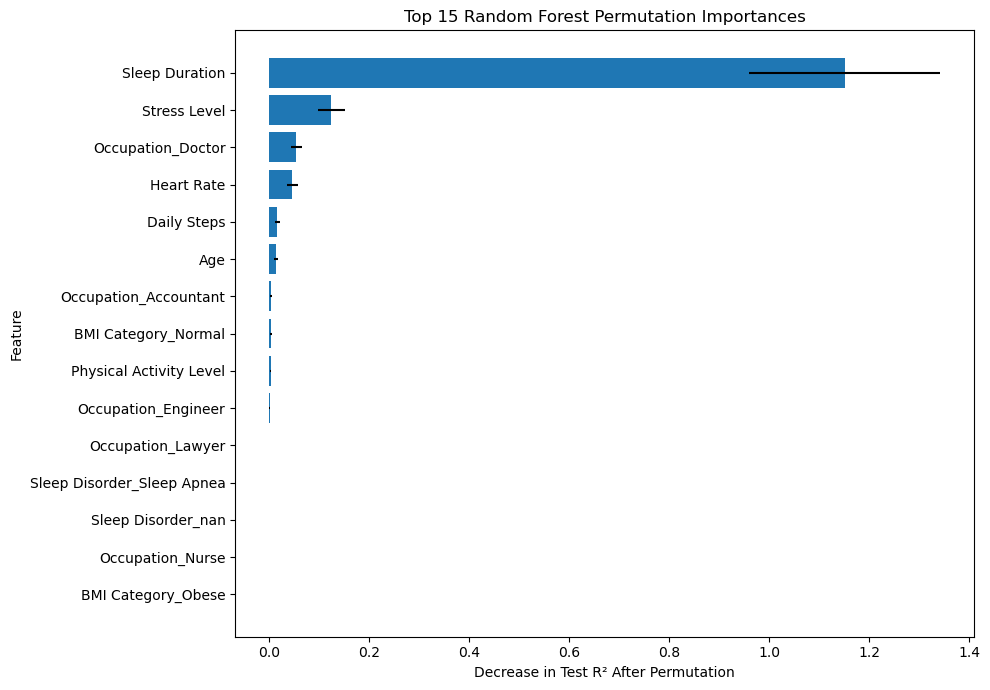

Saved: /Users/home/Desktop/AthleteIQ/athleteiq-performance-prediction/figures/random_forest_permutation_importance.png


In [11]:
top_permutation = permutation_importance_df.head(15).sort_values(
    "Permutation Importance Mean",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_permutation["Feature"],
    top_permutation["Permutation Importance Mean"],
    xerr=top_permutation["Permutation Importance Std"]
)

plt.xlabel("Decrease in Test R² After Permutation")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Permutation Importances")
plt.tight_layout()

permutation_figure_path = FIGURES_DIR / "random_forest_permutation_importance.png"

plt.savefig(
    permutation_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", permutation_figure_path)

In [12]:
importance_comparison = feature_importance_df.merge(
    permutation_importance_df,
    on="Feature"
)

importance_comparison = importance_comparison.sort_values(
    "Permutation Importance Mean",
    ascending=False
).reset_index(drop=True)

importance_comparison.head(15)

,Feature,Importance,Permutation Importance Mean,Permutation Importance Std
0,Sleep Duration,0.794060,1.151418,0.191223
1,Stress Level,0.100867,0.124749,0.027014
2,Occupation_Doctor,0.035611,0.055021,0.011466
3,Heart Rate,0.033957,0.047330,0.010317
4,Daily Steps,0.009012,0.017404,0.004070
5,Age,0.008435,0.014064,0.003980
6,Occupation_Accountant,0.005143,0.005157,0.002129
7,BMI Category_Normal,0.002839,0.005085,0.002134
8,Physical Activity Level,0.001206,0.003684,0.001363
9,Occupation_Engineer,0.000931,0.001481,0.000493


In [13]:
combined_train = X_train.copy()
combined_train["Quality of Sleep"] = y_train.values

target_correlations = (
    combined_train
    .corr(numeric_only=True)["Quality of Sleep"]
    .drop("Quality of Sleep")
    .sort_values(key=abs, ascending=False)
)

target_correlation_df = target_correlations.reset_index()
target_correlation_df.columns = ["Feature", "Correlation with Quality of Sleep"]

target_correlation_df.head(15)

,Feature,Correlation with Quality of Sleep
0,Stress Level,-0.894598
1,Sleep Duration,0.884158
2,Heart Rate,-0.640784
3,Age,0.452331
4,Occupation_Engineer,0.397950
5,Sleep Disorder_Insomnia,-0.331866
6,Sleep Disorder_nan,0.327018
7,BMI Category_Normal,0.326427
8,Occupation_Salesperson,-0.325530
9,BMI Category_Overweight,-0.316201


In [14]:
correlation_path = REPORTS_DIR / "feature_target_correlations.csv"

target_correlation_df.to_csv(
    correlation_path,
    index=False
)

print("Saved:", correlation_path)

Saved: /Users/home/Desktop/AthleteIQ/athleteiq-performance-prediction/reports/feature_target_correlations.csv


## Potential Leakage and Dataset Structure

The Random Forest model achieved an unusually high R².

This does not automatically mean that target leakage occurred.

Several different explanations are possible:

1. The predictor variables may genuinely have very strong relationships with Quality of Sleep.
2. The dataset may contain repeated or nearly repeated participant profiles.
3. Similar feature profiles may appear in both the training and testing datasets.
4. Some predictors may be measured at the same time as the target and therefore provide unusually direct information.
5. The structure of the dataset may make the prediction problem easier than a real-world deployment setting.

The following checks investigate these possibilities.

In [15]:
train_profile_count = X_train.drop_duplicates().shape[0]
test_profile_count = X_test.drop_duplicates().shape[0]

print("Training rows:", len(X_train))
print("Unique training feature profiles:", train_profile_count)

print("\nTest rows:", len(X_test))
print("Unique test feature profiles:", test_profile_count)

print("\nRepeated training profiles:", len(X_train) - train_profile_count)
print("Repeated test profiles:", len(X_test) - test_profile_count)

Training rows: 299
Unique training feature profiles: 122

Test rows: 75
Unique test feature profiles: 54

Repeated training profiles: 177
Repeated test profiles: 21


In [16]:
train_profiles = set(
    map(tuple, X_train.to_numpy())
)

test_profiles = list(
    map(tuple, X_test.to_numpy())
)

test_overlap_mask = pd.Series(
    [profile in train_profiles for profile in test_profiles]
)

unique_test_profiles = set(test_profiles)

overlapping_unique_profiles = train_profiles.intersection(
    unique_test_profiles
)

test_rows_seen_in_training = int(test_overlap_mask.sum())
test_overlap_percentage = (
    test_rows_seen_in_training / len(X_test) * 100
)

print("Unique training profiles:", len(train_profiles))
print("Unique test profiles:", len(unique_test_profiles))
print("Unique feature profiles appearing in both sets:", len(overlapping_unique_profiles))

print(
    "\nTest rows whose exact feature profile appeared in training:",
    test_rows_seen_in_training,
    "/",
    len(X_test)
)

print(
    f"Percentage of test rows with a profile seen during training: "
    f"{test_overlap_percentage:.2f}%"
)

Unique training profiles: 122
Unique test profiles: 54
Unique feature profiles appearing in both sets: 44

Test rows whose exact feature profile appeared in training: 65 / 75
Percentage of test rows with a profile seen during training: 86.67%


In [17]:
all_X = pd.concat(
    [X_train, X_test],
    ignore_index=True
)

all_y = pd.concat(
    [y_train, y_test],
    ignore_index=True
)

all_data = all_X.copy()
all_data["Quality of Sleep"] = all_y.values

print("Combined rows:", len(all_data))
print("Combined features:", all_X.shape[1])

Combined rows: 374
Combined features: 27


In [18]:
profile_summary = (
    all_data
    .groupby(list(all_X.columns), dropna=False)["Quality of Sleep"]
    .agg(["count", "nunique"])
    .reset_index()
)

repeated_profiles = profile_summary[
    profile_summary["count"] > 1
]

conflicting_profiles = profile_summary[
    profile_summary["nunique"] > 1
]

print("Total unique predictor profiles:", len(profile_summary))
print("Repeated predictor profiles:", len(repeated_profiles))
print("Profiles associated with multiple target values:", len(conflicting_profiles))

Total unique predictor profiles: 132
Repeated predictor profiles: 78
Profiles associated with multiple target values: 0


In [19]:
rows_in_repeated_profiles = repeated_profiles["count"].sum()

percentage_rows_repeated = (
    rows_in_repeated_profiles / len(all_data) * 100
)

print("Rows belonging to repeated predictor profiles:", rows_in_repeated_profiles)
print(
    f"Percentage of all rows belonging to repeated profiles: "
    f"{percentage_rows_repeated:.2f}%"
)

Rows belonging to repeated predictor profiles: 320
Percentage of all rows belonging to repeated profiles: 85.56%


In [20]:
leakage_checks_df = pd.DataFrame({
    "Metric": [
        "Training rows",
        "Unique training profiles",
        "Test rows",
        "Unique test profiles",
        "Unique profiles appearing in both train and test",
        "Test rows with profile seen in training",
        "Test overlap percentage",
        "Total unique predictor profiles",
        "Repeated predictor profiles",
        "Profiles with multiple target values",
        "Rows belonging to repeated profiles",
        "Percentage rows belonging to repeated profiles"
    ],
    "Value": [
        len(X_train),
        len(train_profiles),
        len(X_test),
        len(unique_test_profiles),
        len(overlapping_unique_profiles),
        test_rows_seen_in_training,
        test_overlap_percentage,
        len(profile_summary),
        len(repeated_profiles),
        len(conflicting_profiles),
        rows_in_repeated_profiles,
        percentage_rows_repeated
    ]
})

leakage_checks_df

,Metric,Value
0,Training rows,299.000000
1,Unique training profiles,122.000000
2,Test rows,75.000000
3,Unique test profiles,54.000000
4,Unique profiles appearing in both train and test,44.000000
5,Test rows with profile seen in training,65.000000
6,Test overlap percentage,86.666667
7,Total unique predictor profiles,132.000000
8,Repeated predictor profiles,78.000000
9,Profiles with multiple target values,0.000000


In [21]:
leakage_path = REPORTS_DIR / "data_leakage_profile_checks.csv"

leakage_checks_df.to_csv(
    leakage_path,
    index=False
)

print("Saved:", leakage_path)

Saved: /Users/home/Desktop/AthleteIQ/athleteiq-performance-prediction/reports/data_leakage_profile_checks.csv


## Feature Ablation Analysis

Feature ablation evaluates how model performance changes when selected predictors are removed.

This does not prove that a feature is leaking information.

Instead, it helps determine how dependent the model is on particular variables.

Sleep Duration and Stress Level are especially important to examine because exploratory analysis showed very strong relationships with Quality of Sleep.

Sleep Disorder is also examined because its availability may depend on the intended prediction scenario.

In [22]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def evaluate_feature_subset(name, X):
    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    
    scores = cross_val_score(
        model,
        X,
        y_train,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )
    
    return {
        "Feature Set": name,
        "Number of Features": X.shape[1],
        "Mean CV R²": scores.mean(),
        "Std CV R²": scores.std()
    }

In [23]:
sleep_disorder_columns = [
    col for col in X_train.columns
    if col.startswith("Sleep Disorder_")
]

feature_sets = {
    "All Features": X_train,
    
    "Without Sleep Duration": X_train.drop(
        columns=["Sleep Duration"]
    ),
    
    "Without Stress Level": X_train.drop(
        columns=["Stress Level"]
    ),
    
    "Without Sleep Duration + Stress Level": X_train.drop(
        columns=["Sleep Duration", "Stress Level"]
    ),
    
    "Without Sleep Disorder": X_train.drop(
        columns=sleep_disorder_columns
    ),
    
    "Without Sleep Duration + Stress Level + Sleep Disorder": X_train.drop(
        columns=[
            "Sleep Duration",
            "Stress Level",
            *sleep_disorder_columns
        ]
    )
}

for name, feature_data in feature_sets.items():
    print(name, "->", feature_data.shape[1], "features")

All Features -> 27 features
Without Sleep Duration -> 26 features
Without Stress Level -> 26 features
Without Sleep Duration + Stress Level -> 25 features
Without Sleep Disorder -> 24 features
Without Sleep Duration + Stress Level + Sleep Disorder -> 22 features


In [24]:
ablation_results = []

for name, feature_data in feature_sets.items():
    result = evaluate_feature_subset(
        name,
        feature_data
    )
    
    ablation_results.append(result)

ablation_results_df = pd.DataFrame(
    ablation_results
).sort_values(
    "Mean CV R²",
    ascending=False
).reset_index(drop=True)

ablation_results_df

,Feature Set,Number of Features,Mean CV R²,Std CV R²
0,All Features,27,0.979606,0.013499
1,Without Sleep Disorder,24,0.978396,0.014962
2,Without Sleep Duration,26,0.975653,0.015049
3,Without Stress Level,26,0.972822,0.017702
4,Without Sleep Duration + Stress Level + Sleep ...,22,0.911636,0.085690
5,Without Sleep Duration + Stress Level,25,0.909675,0.087698


In [25]:
full_model_r2 = ablation_results_df.loc[
    ablation_results_df["Feature Set"] == "All Features",
    "Mean CV R²"
].iloc[0]

ablation_results_df["R² Change vs All Features"] = (
    ablation_results_df["Mean CV R²"] - full_model_r2
)

ablation_results_df

,Feature Set,Number of Features,Mean CV R²,Std CV R²,R² Change vs All Features
0,All Features,27,0.979606,0.013499,0.000000
1,Without Sleep Disorder,24,0.978396,0.014962,-0.001211
2,Without Sleep Duration,26,0.975653,0.015049,-0.003953
3,Without Stress Level,26,0.972822,0.017702,-0.006784
4,Without Sleep Duration + Stress Level + Sleep ...,22,0.911636,0.085690,-0.067971
5,Without Sleep Duration + Stress Level,25,0.909675,0.087698,-0.069931


In [26]:
ablation_path = REPORTS_DIR / "random_forest_ablation_results.csv"

ablation_results_df.to_csv(
    ablation_path,
    index=False
)

print("Saved:", ablation_path)

Saved: /Users/home/Desktop/AthleteIQ/athleteiq-performance-prediction/reports/random_forest_ablation_results.csv


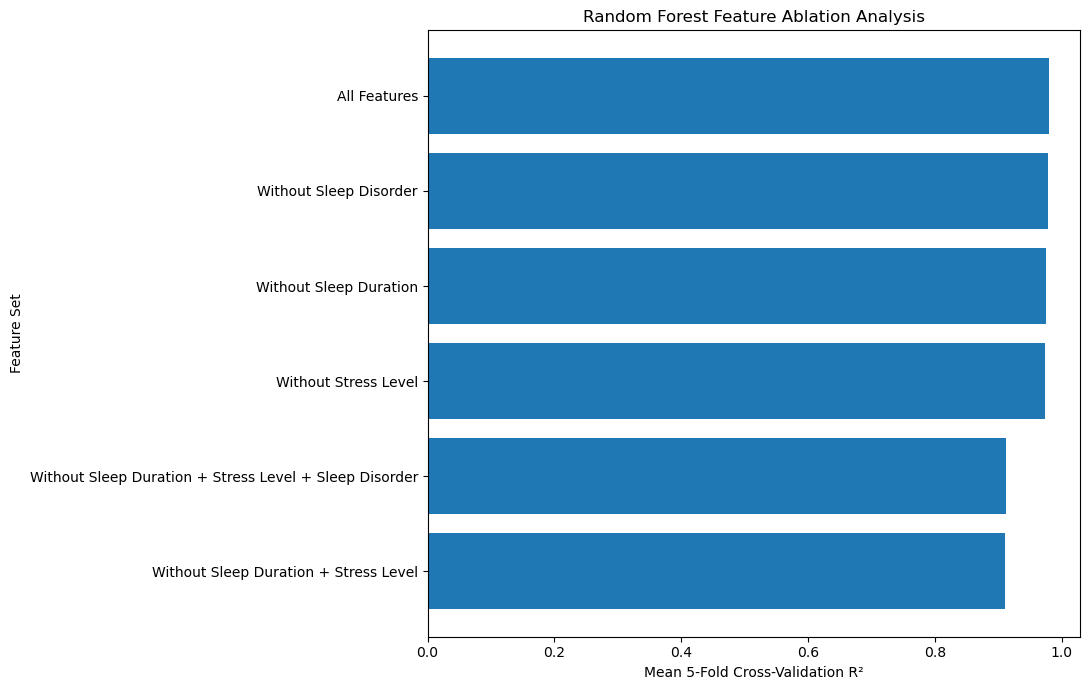

Saved: /Users/home/Desktop/AthleteIQ/athleteiq-performance-prediction/figures/random_forest_ablation_analysis.png


In [27]:
plot_ablation = ablation_results_df.sort_values(
    "Mean CV R²",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    plot_ablation["Feature Set"],
    plot_ablation["Mean CV R²"]
)

plt.xlabel("Mean 5-Fold Cross-Validation R²")
plt.ylabel("Feature Set")
plt.title("Random Forest Feature Ablation Analysis")
plt.tight_layout()

ablation_figure_path = FIGURES_DIR / "random_forest_ablation_analysis.png"

plt.savefig(
    ablation_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", ablation_figure_path)

## Leakage Interpretation

Several different concepts should be distinguished.

### Direct Target Leakage

Direct target leakage would occur if `Quality of Sleep` itself, or information derived directly from it, were included among the predictors.

The integrity checks confirmed that `Quality of Sleep` is not present in the feature matrix.

### Train-Test Profile Overlap

Identical predictor profiles appearing in both training and testing data are not necessarily target leakage.

However, they reduce the independence between the training and testing datasets and may cause a random split to produce overly optimistic performance.

### Feature Availability

Some predictors may be strongly associated with the target because they are measured at approximately the same time.

For example, if the objective were to predict future sleep quality before a night's sleep occurs, the same night's Sleep Duration would not yet be available.

Therefore, whether a feature should be considered appropriate depends on the intended prediction scenario.

### Preprocessing Design

For the current baseline workflow, feature engineering was performed before the train-test split.

One-hot encoding does not use the target variable, so this is much lower risk than target-based preprocessing. However, a production-quality machine-learning workflow should fit preprocessing transformations using training data only, normally through a scikit-learn Pipeline or ColumnTransformer.

This improvement should be implemented during the robust final modeling stage.

In [28]:
top_impurity = feature_importance_df.iloc[0]
top_permutation = permutation_importance_df.iloc[0]

print("=" * 65)
print("DAY 8 RESULT SNAPSHOT")
print("=" * 65)

print("\nTop impurity-based feature:")
print(
    f"{top_impurity['Feature']} "
    f"({top_impurity['Importance']:.4f})"
)

print("\nTop permutation-importance feature:")
print(
    f"{top_permutation['Feature']} "
    f"({top_permutation['Permutation Importance Mean']:.4f})"
)

print("\nTrain/Test Profile Overlap:")
print(
    f"Unique feature profiles appearing in both sets: "
    f"{len(overlapping_unique_profiles)}"
)

print(
    f"Test rows with profiles seen during training: "
    f"{test_rows_seen_in_training}/{len(X_test)} "
    f"({test_overlap_percentage:.2f}%)"
)

print("\nDataset Profile Structure:")
print(
    f"Unique predictor profiles: "
    f"{len(profile_summary)}"
)

print(
    f"Repeated predictor profiles: "
    f"{len(repeated_profiles)}"
)

print(
    f"Profiles with multiple target values: "
    f"{len(conflicting_profiles)}"
)

print(
    f"Rows belonging to repeated profiles: "
    f"{rows_in_repeated_profiles}/{len(all_data)} "
    f"({percentage_rows_repeated:.2f}%)"
)

print("\nAblation Results:")
for _, row in ablation_results_df.iterrows():
    print(
        f"{row['Feature Set']}: "
        f"CV R² = {row['Mean CV R²']:.4f} "
        f"(change = {row['R² Change vs All Features']:+.4f})"
    )

print("\nDay 8 analysis completed successfully.")

DAY 8 RESULT SNAPSHOT

Top impurity-based feature:
Sleep Duration (0.7941)

Top permutation-importance feature:
Sleep Duration (1.1514)

Train/Test Profile Overlap:
Unique feature profiles appearing in both sets: 44
Test rows with profiles seen during training: 65/75 (86.67%)

Dataset Profile Structure:
Unique predictor profiles: 132
Repeated predictor profiles: 78
Profiles with multiple target values: 0
Rows belonging to repeated profiles: 320/374 (85.56%)

Ablation Results:
All Features: CV R² = 0.9796 (change = +0.0000)
Without Sleep Disorder: CV R² = 0.9784 (change = -0.0012)
Without Sleep Duration: CV R² = 0.9757 (change = -0.0040)
Without Stress Level: CV R² = 0.9728 (change = -0.0068)
Without Sleep Duration + Stress Level + Sleep Disorder: CV R² = 0.9116 (change = -0.0680)
Without Sleep Duration + Stress Level: CV R² = 0.9097 (change = -0.0699)

Day 8 analysis completed successfully.


## Day 8 Summary

The Random Forest model was interpreted using both impurity-based feature importance and permutation importance.

Additional diagnostic analysis investigated whether repeated predictor profiles or overlap between the training and testing datasets could contribute to the unusually strong predictive performance.

Feature ablation experiments were also performed to determine how strongly the model depends on Sleep Duration, Stress Level, and Sleep Disorder information.

These analyses provide a more complete understanding of model behavior than predictive accuracy alone.

The next modeling decisions should be based on these diagnostic findings rather than attempting to maximize R² immediately.